In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

FILE_PATH = r"C:\Users\Dell\Desktop\fish_farming_dataset.csv"
df = pd.read_csv(FILE_PATH)


# Feature engineering 
df['Profit']         = df['Revenue'] - df['Feed_Cost']
df['Profit_Margin']  = (df['Profit'] / df['Revenue']) * 100
df['Yield_per_m2']   = df['Harvest_Weight'] / df['Pond_Size_m2']
df['Cost_per_kg']    = df['Feed_Cost'] / df['Harvest_Weight']
df['High_Mortality'] = (df['Mortality_Rate'] > df['Mortality_Rate'].median()).astype(int)

print("Dataset loaded successfully!")
print(f"Shape : {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")
print(df[['Farm_ID','Province','Feed_Type','Pond_Size_m2',
          'Stocking_Density','Revenue','Mortality_Rate']].head(10).to_string())

Dataset loaded successfully!
Shape : (1000, 20)
Columns: ['Farm_ID', 'Province', 'Pond_Size_m2', 'Stocking_Density', 'Feed_Type', 'Feed_Cost', 'Feeding_Frequency', 'Water_Temperature', 'Water_pH', 'Oxygen_Level', 'Growth_Rate', 'Mortality_Rate', 'Harvest_Weight', 'Market_Price', 'Revenue', 'Profit', 'Profit_Margin', 'Yield_per_m2', 'Cost_per_kg', 'High_Mortality']

  Farm_ID    Province Feed_Type  Pond_Size_m2  Stocking_Density   Revenue  Mortality_Rate
0   F0001     Eastern  Imported          1965                13  408427.8             3.1
1   F0002     Western     Local          1099                 7  153606.5             2.6
2   F0003     Eastern     Local           240                12   45952.5             3.3
3   F0004     Central     Local          1710                 7  241996.8            12.1
4   F0005  Copperbelt  Imported           215                20   67769.6             1.5
5   F0006  Copperbelt  Imported           374                 9   63928.8             2.6
6 

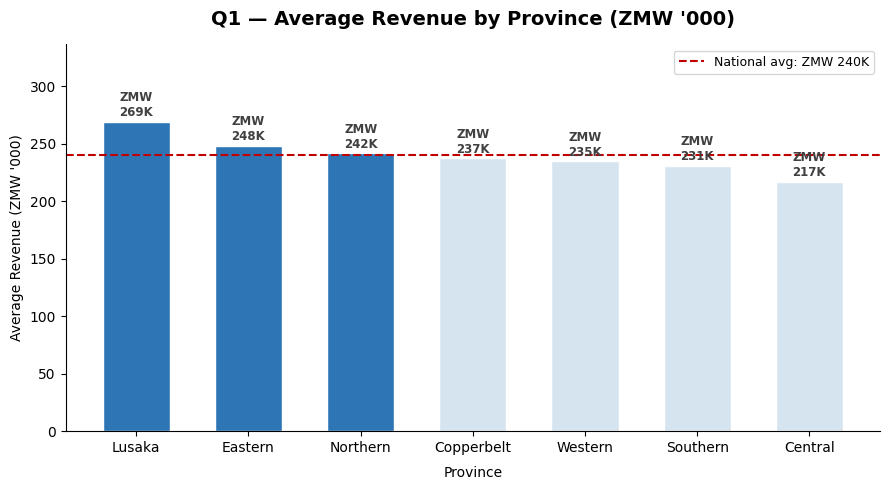

Province
Lusaka        269037.0
Eastern       248294.0
Northern      241944.0
Copperbelt    237461.0
Western       235000.0
Southern      230891.0
Central       217110.0
Name: Revenue, dtype: float64


In [2]:
#  Q1: Average revenue by province 
prov_rev = df.groupby('Province')['Revenue'].mean().sort_values(ascending=False)
avg_rev  = prov_rev.mean()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2E75B6' if v >= avg_rev else '#D6E4F0' for v in prov_rev.values]
bars = ax.bar(prov_rev.index, prov_rev.values / 1000,
              color=colors, edgecolor='white', width=0.6)

ax.axhline(avg_rev / 1000, color='#C00000', linestyle='--', linewidth=1.5,
           label=f'National avg: ZMW {avg_rev/1000:.0f}K')

for bar, val in zip(bars, prov_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"ZMW\n{val/1000:.0f}K", ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color='#404040')

ax.set_title("Q1 — Average Revenue by Province (ZMW '000)",
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel("Province", labelpad=8)
ax.set_ylabel("Average Revenue (ZMW '000)")
ax.set_ylim(0, prov_rev.max() / 1000 * 1.25)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(prov_rev.round(0))

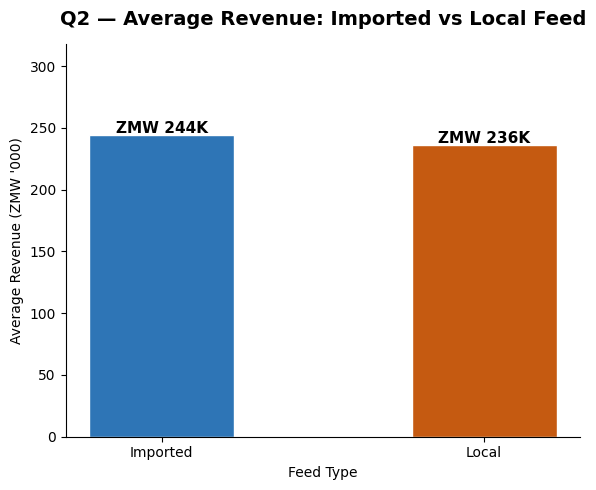

Imported avg : ZMW 244,281
Local avg    : ZMW 235,940
Difference   : ZMW 8,341  (3.5% premium)


In [3]:
# ── Q2: Revenue by feed type ──────────────────────────────────────────────────
feed_rev = df.groupby('Feed_Type')['Revenue'].mean()

fig, ax = plt.subplots(figsize=(6, 5))
bars2 = ax.bar(feed_rev.index, feed_rev.values / 1000,
               color=['#2E75B6', '#C55A11'], edgecolor='white', width=0.45)

for bar, val in zip(bars2, feed_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"ZMW {val/1000:.0f}K", ha='center', fontsize=11, fontweight='bold')

ax.set_title("Q2 — Average Revenue: Imported vs Local Feed",
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel("Feed Type")
ax.set_ylabel("Average Revenue (ZMW '000)")
ax.set_ylim(0, feed_rev.max() / 1000 * 1.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

diff = feed_rev['Imported'] - feed_rev['Local']
print(f"Imported avg : ZMW {feed_rev['Imported']:,.0f}")
print(f"Local avg    : ZMW {feed_rev['Local']:,.0f}")
print(f"Difference   : ZMW {diff:,.0f}  ({diff/feed_rev['Local']*100:.1f}% premium)")

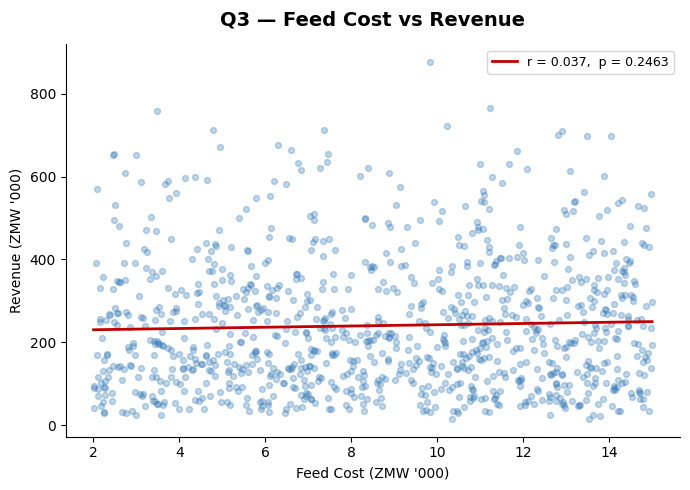

Pearson r = 0.037,  p = 0.2463
→ No significant linear relationship between feed cost and revenue


In [4]:
#Q3: Feed cost vs Revenue
r3, p3 = stats.pearsonr(df['Feed_Cost'], df['Revenue'])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['Feed_Cost'] / 1000, df['Revenue'] / 1000,
           alpha=0.3, color='#2E75B6', s=18)

m, b = np.polyfit(df['Feed_Cost'], df['Revenue'], 1)
x_line = np.linspace(df['Feed_Cost'].min(), df['Feed_Cost'].max(), 100)
ax.plot(x_line / 1000, (m * x_line + b) / 1000,
        color='#C00000', linewidth=2, label=f'r = {r3:.3f},  p = {p3:.4f}')

ax.set_title("Q3 — Feed Cost vs Revenue", fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel("Feed Cost (ZMW '000)")
ax.set_ylabel("Revenue (ZMW '000)")
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Pearson r = {r3:.3f},  p = {p3:.4f}")
print("→ No significant linear relationship between feed cost and revenue")

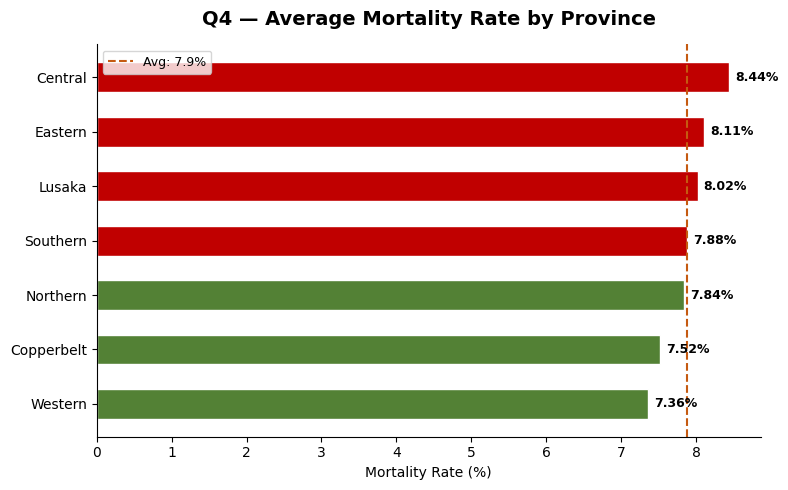

Province
Western       7.36
Copperbelt    7.52
Northern      7.84
Southern      7.88
Lusaka        8.02
Eastern       8.11
Central       8.44
Name: Mortality_Rate, dtype: float64


In [5]:
# ── Q4: Mortality rate by province ────────────────────────────────────────────
prov_mort = df.groupby('Province')['Mortality_Rate'].mean().sort_values(ascending=True)
avg_mort  = prov_mort.mean()

fig, ax = plt.subplots(figsize=(8, 5))
colors5 = ['#C00000' if v > avg_mort else '#538135' for v in prov_mort.values]
hbars = ax.barh(prov_mort.index, prov_mort.values,
                color=colors5, edgecolor='white', height=0.55)

ax.axvline(avg_mort, color='#C55A11', linestyle='--', linewidth=1.5,
           label=f'Avg: {avg_mort:.1f}%')

for bar, val in zip(hbars, prov_mort.values):
    ax.text(val + 0.08, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')

ax.set_title("Q4 — Average Mortality Rate by Province",
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel("Mortality Rate (%)")
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(prov_mort.round(2))

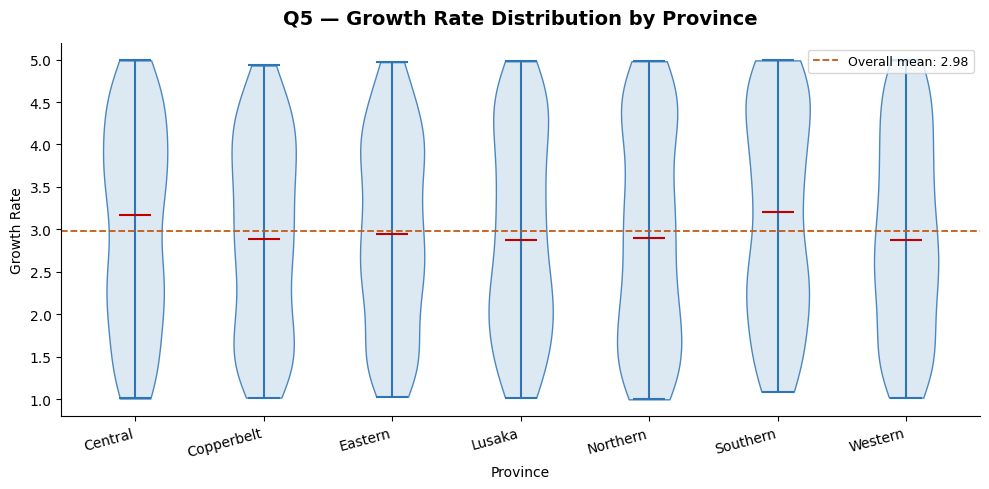

In [ ]:
# Q5: Growth rate violin plot 
fig, ax = plt.subplots(figsize=(10, 5))
provinces = sorted(df['Province'].unique())
data_gr   = [df[df['Province'] == p]['Growth_Rate'].values for p in provinces]

parts = ax.violinplot(data_gr, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#D6E4F0')
    pc.set_edgecolor('#2E75B6')
    pc.set_alpha(0.85)
parts['cmedians'].set_color('#C00000')
parts['cbars'].set_color('#2E75B6')
parts['cmaxes'].set_color('#2E75B6')
parts['cmins'].set_color('#2E75B6')

ax.set_xticks(range(1, len(provinces) + 1))
ax.set_xticklabels(provinces, rotation=15, ha='right')
ax.axhline(df['Growth_Rate'].mean(), color='#C55A11', linestyle='--',
           linewidth=1.3, label=f"Overall mean: {df['Growth_Rate'].mean():.2f}")
ax.set_title("Q5 — Growth Rate Distribution by Province",
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel("Province")
ax.set_ylabel("Growth Rate")
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

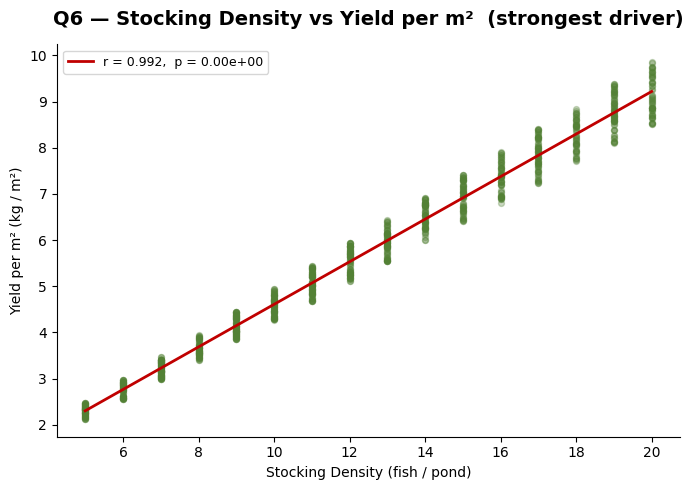

Pearson r = 0.992,  p = 0.00e+00
→ Near-perfect positive relationship — stocking density is the #1 yield driver


In [7]:
# ── Q6: Stocking density vs Yield per m² ─────────────────────────────────────
r6, p6 = stats.pearsonr(df['Stocking_Density'], df['Yield_per_m2'])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['Stocking_Density'], df['Yield_per_m2'],
           alpha=0.3, color='#538135', s=18)

m6, b6 = np.polyfit(df['Stocking_Density'], df['Yield_per_m2'], 1)
x6 = np.linspace(df['Stocking_Density'].min(), df['Stocking_Density'].max(), 100)
ax.plot(x6, m6 * x6 + b6, color='#C00000', linewidth=2,
        label=f'r = {r6:.3f},  p = {p6:.2e}')

ax.set_title("Q6 — Stocking Density vs Yield per m²  (strongest driver)",
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel("Stocking Density (fish / pond)")
ax.set_ylabel("Yield per m² (kg / m²)")
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Pearson r = {r6:.3f},  p = {p6:.2e}")
print("→ Near-perfect positive relationship — stocking density is the #1 yield driver")

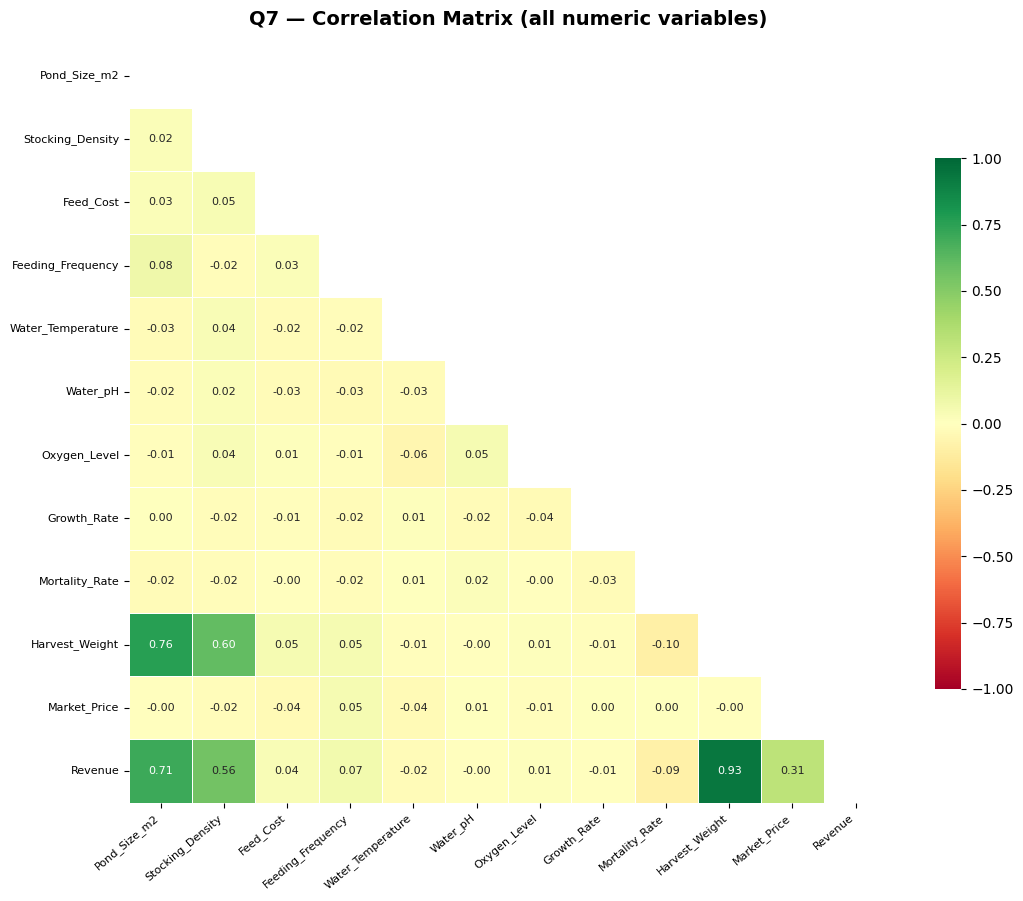


Top correlations with Revenue:
Harvest_Weight       0.930
Pond_Size_m2         0.710
Stocking_Density     0.558
Market_Price         0.311
Feeding_Frequency    0.069
Feed_Cost            0.037


In [8]:
# ── Q7: Correlation heatmap ───────────────────────────────────────────────────
numeric_cols = ['Pond_Size_m2','Stocking_Density','Feed_Cost','Feeding_Frequency',
                'Water_Temperature','Water_pH','Oxygen_Level','Growth_Rate',
                'Mortality_Rate','Harvest_Weight','Market_Price','Revenue']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7}, annot_kws={'size': 8})
ax.set_title("Q7 — Correlation Matrix (all numeric variables)",
             fontsize=14, fontweight='bold', pad=14)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print("\nTop correlations with Revenue:")
print(corr_matrix['Revenue'].sort_values(ascending=False)
      .drop('Revenue').head(6).round(3).to_string())

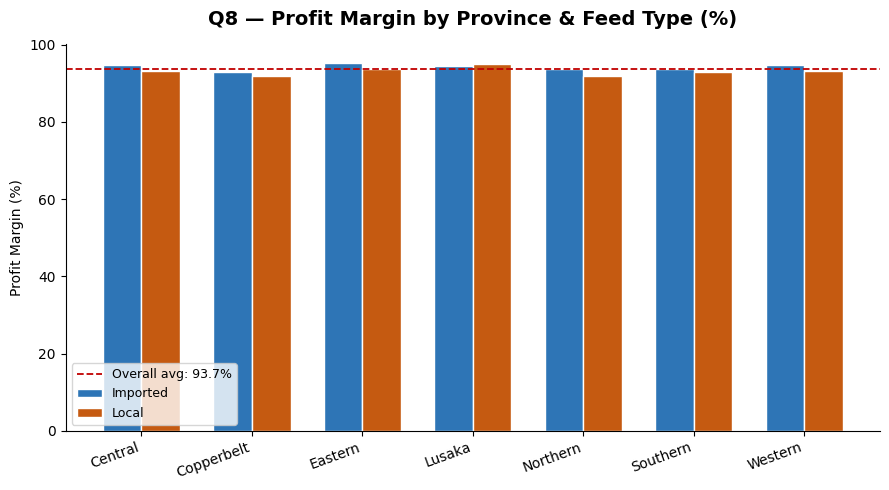

In [9]:
# ── Q8: Profit margin grouped bar ─────────────────────────────────────────────
pm_pivot = df.pivot_table(values='Profit_Margin',
                          index='Province', columns='Feed_Type', aggfunc='mean')
x = np.arange(len(pm_pivot.index))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, pm_pivot['Imported'], width=w, color='#2E75B6',
       label='Imported', edgecolor='white')
ax.bar(x + w/2, pm_pivot['Local'],    width=w, color='#C55A11',
       label='Local',    edgecolor='white')
ax.axhline(df['Profit_Margin'].mean(), color='#C00000', linestyle='--',
           linewidth=1.3, label=f"Overall avg: {df['Profit_Margin'].mean():.1f}%")

ax.set_xticks(x)
ax.set_xticklabels(pm_pivot.index, rotation=20, ha='right')
ax.set_title("Q8 — Profit Margin by Province & Feed Type (%)",
             fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel("Profit Margin (%)")
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

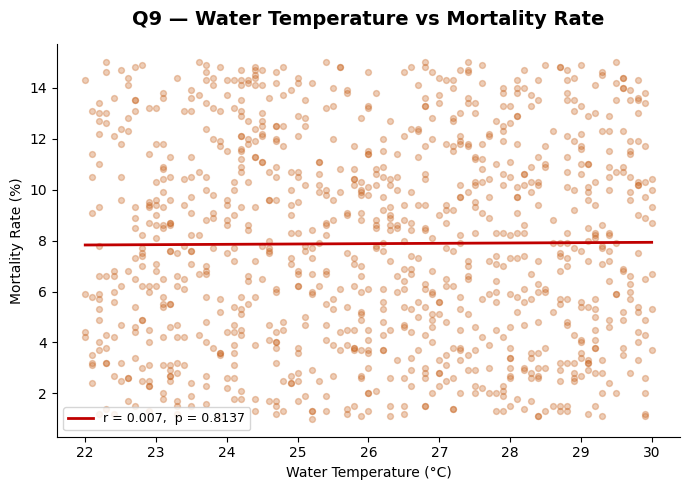

Pearson r = 0.007,  p = 0.8137
→ Temperature not a significant mortality driver within 22–30 °C range


In [10]:
# ── Q9: Water temperature vs Mortality ───────────────────────────────────────
r9, p9 = stats.pearsonr(df['Water_Temperature'], df['Mortality_Rate'])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['Water_Temperature'], df['Mortality_Rate'],
           alpha=0.3, color='#C55A11', s=18)

m9, b9 = np.polyfit(df['Water_Temperature'], df['Mortality_Rate'], 1)
x9 = np.linspace(df['Water_Temperature'].min(), df['Water_Temperature'].max(), 100)
ax.plot(x9, m9 * x9 + b9, color='#C00000', linewidth=2,
        label=f'r = {r9:.3f},  p = {p9:.4f}')

ax.set_title("Q9 — Water Temperature vs Mortality Rate",
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel("Water Temperature (°C)")
ax.set_ylabel("Mortality Rate (%)")
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Pearson r = {r9:.3f},  p = {p9:.4f}")
print("→ Temperature not a significant mortality driver within 22–30 °C range")

In [11]:
# ── Summary ───────────────────────────────────────────────────────────────────
r_harvest, _ = stats.pearsonr(df['Harvest_Weight'], df['Revenue'])
r_pond,    _ = stats.pearsonr(df['Pond_Size_m2'],   df['Revenue'])

print("=" * 60)
print("  FISH FARMING ANALYSIS — KEY FINDINGS")
print("=" * 60)
print(f"  Total farms analysed  : {len(df):,}")
print(f"  Provinces covered     : {df['Province'].nunique()}")
print(f"  Avg revenue           : ZMW {df['Revenue'].mean():,.0f}")
print(f"  Avg mortality rate    : {df['Mortality_Rate'].mean():.2f}%")
print(f"  Avg growth rate       : {df['Growth_Rate'].mean():.2f}")
print(f"  Avg profit margin     : {df['Profit_Margin'].mean():.1f}%")
print("─" * 60)
print(f"  Stocking vs Yield r   : {r6:.3f}  (p < 0.001) ← #1 driver")
print(f"  Harvest Wt vs Revenue : {r_harvest:.3f}  (p < 0.001)")
print(f"  Pond Size vs Revenue  : {r_pond:.3f}  (p < 0.001)")
print(f"  Feed Cost vs Revenue  : {r3:.3f}  (p = {p3:.4f}) ← NOT significant")
print(f"  Temperature vs Mort   : {r9:.3f}  (p = {p9:.4f}) ← NOT significant")
print("─" * 60)
print(f"  Top revenue province  : {prov_rev.idxmax()} (ZMW {prov_rev.max():,.0f})")
print(f"  Lowest revenue        : {prov_rev.idxmin()} (ZMW {prov_rev.min():,.0f})")
print(f"  Highest mortality     : {prov_mort.idxmax()} ({prov_mort.max():.2f}%)")
print(f"  Lowest mortality      : {prov_mort.idxmin()} ({prov_mort.min():.2f}%)")
print("=" * 60)

  FISH FARMING ANALYSIS — KEY FINDINGS
  Total farms analysed  : 1,000
  Provinces covered     : 7
  Avg revenue           : ZMW 240,269
  Avg mortality rate    : 7.88%
  Avg growth rate       : 2.98
  Avg profit margin     : 93.7%
────────────────────────────────────────────────────────────
  Stocking vs Yield r   : 0.992  (p < 0.001) ← #1 driver
  Harvest Wt vs Revenue : 0.930  (p < 0.001)
  Pond Size vs Revenue  : 0.710  (p < 0.001)
  Feed Cost vs Revenue  : 0.037  (p = 0.2463) ← NOT significant
  Temperature vs Mort   : 0.007  (p = 0.8137) ← NOT significant
────────────────────────────────────────────────────────────
  Top revenue province  : Lusaka (ZMW 269,037)
  Lowest revenue        : Central (ZMW 217,110)
  Highest mortality     : Central (8.44%)
  Lowest mortality      : Western (7.36%)
